# Week 6 Assessment — Autoencoder for Image Denoising (MNIST)

**Task:** Build a deep learning model that removes noise from images using an autoencoder, trained on MNIST.

Steps covered (per assignment):
1. Load and preprocess the MNIST dataset
2. Add artificial noise to create noisy input images
3. Build and train a Denoising Autoencoder (noisy in -> clean target)
4. Generate denoised outputs on the test set
5. Results, visualization, and observations


In [5]:
# 1. Imports
import os
import glob
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## Step 1: Load and preprocess the MNIST dataset (from the provided Kaggle PNG dataset)

In [4]:
ZIP_PATH = "archive (2).zip"
EXTRACT_DIR = "mnist_data"

if not os.path.isdir(os.path.join(EXTRACT_DIR, "mnist_png")):
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)

TRAIN_DIR = os.path.join(EXTRACT_DIR, "mnist_png", "training")
TEST_DIR = os.path.join(EXTRACT_DIR, "mnist_png", "testing")


def load_images_from_folder(folder):
    images, labels = [], []
    for digit in range(10):
        digit_folder = os.path.join(folder, str(digit))
        for file_path in glob.glob(os.path.join(digit_folder, "*.png")):
            img = Image.open(file_path).convert("L")  # ensure grayscale
            images.append(np.array(img))
            labels.append(digit)
    return np.array(images), np.array(labels)


x_train, y_train = load_images_from_folder(TRAIN_DIR)
x_test, y_test = load_images_from_folder(TEST_DIR)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to (28, 28, 1) for Conv2D layers
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("After preprocessing:", x_train.shape, x_test.shape)


Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
After preprocessing: (60000, 28, 28, 1) (10000, 28, 28, 1)


## Step 2: Add artificial noise to create noisy input images

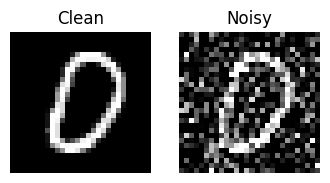

In [6]:
NOISE_FACTOR = 0.4

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    # Pixel values must stay valid images -> clip back to [0, 1]
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy.astype("float32")

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

# Quick sanity check: show a clean vs noisy pair
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.title("Clean")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(x_train_noisy[0].squeeze(), cmap="gray")
plt.title("Noisy")
plt.axis("off")
plt.show()


## Step 3: Build and train a Denoising Autoencoder

Encoder: Conv2D + MaxPooling layers progressively compress the 28x28 image into a
smaller spatial/feature representation (the "bottleneck").

Decoder: Conv2D + UpSampling layers mirror the encoder to reconstruct a
28x28 image from the bottleneck representation.

Training pair: noisy image -> clean image (this is what makes it a *denoising*
autoencoder rather than a plain reconstruction autoencoder).


In [7]:
def build_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))

    # ---- Encoder ----
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)          # 28x28 -> 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x)    # 14x14 -> 7x7

    # ---- Decoder ----
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D((2, 2))(x)                          # 7x7 -> 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)                          # 14x14 -> 28x28
    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    autoencoder = models.Model(input_img, decoded, name="denoising_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 20
BATCH_SIZE = 128

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy, x_train,              # noisy input -> clean target
    validation_data=(x_test_noisy, x_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 249ms/step - loss: 0.1449 - val_loss: 0.1020
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 246ms/step - loss: 0.0991 - val_loss: 0.0951
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 245ms/step - loss: 0.0945 - val_loss: 0.0925
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.0922 - val_loss: 0.0906
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 243ms/step - loss: 0.0908 - val_loss: 0.0894
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 246ms/step - loss: 0.0897 - val_loss: 0.0885
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 244ms/step - loss: 0.0889 - val_loss: 0.0878
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 244ms/step - loss: 0.0882 - val_loss: 0.0873
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 242ms/step - loss: 0.0878 - val_loss: 0.0869
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 147s 252ms/step - loss: 0.0873 - val_loss: 0.0865
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 244ms/step - loss: 0.0870 - val_loss: 0.0862
Epoch 12

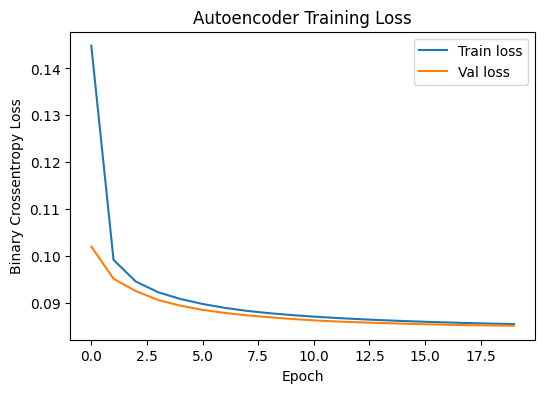

In [9]:
# Training curve
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.show()


## Step 4: Generate denoised outputs on the test set

In [10]:
denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised output shape:", denoised_images.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Denoised output shape: (10000, 28, 28, 1)


## Step 5: Result visualization — Original vs Noisy vs Reconstructed

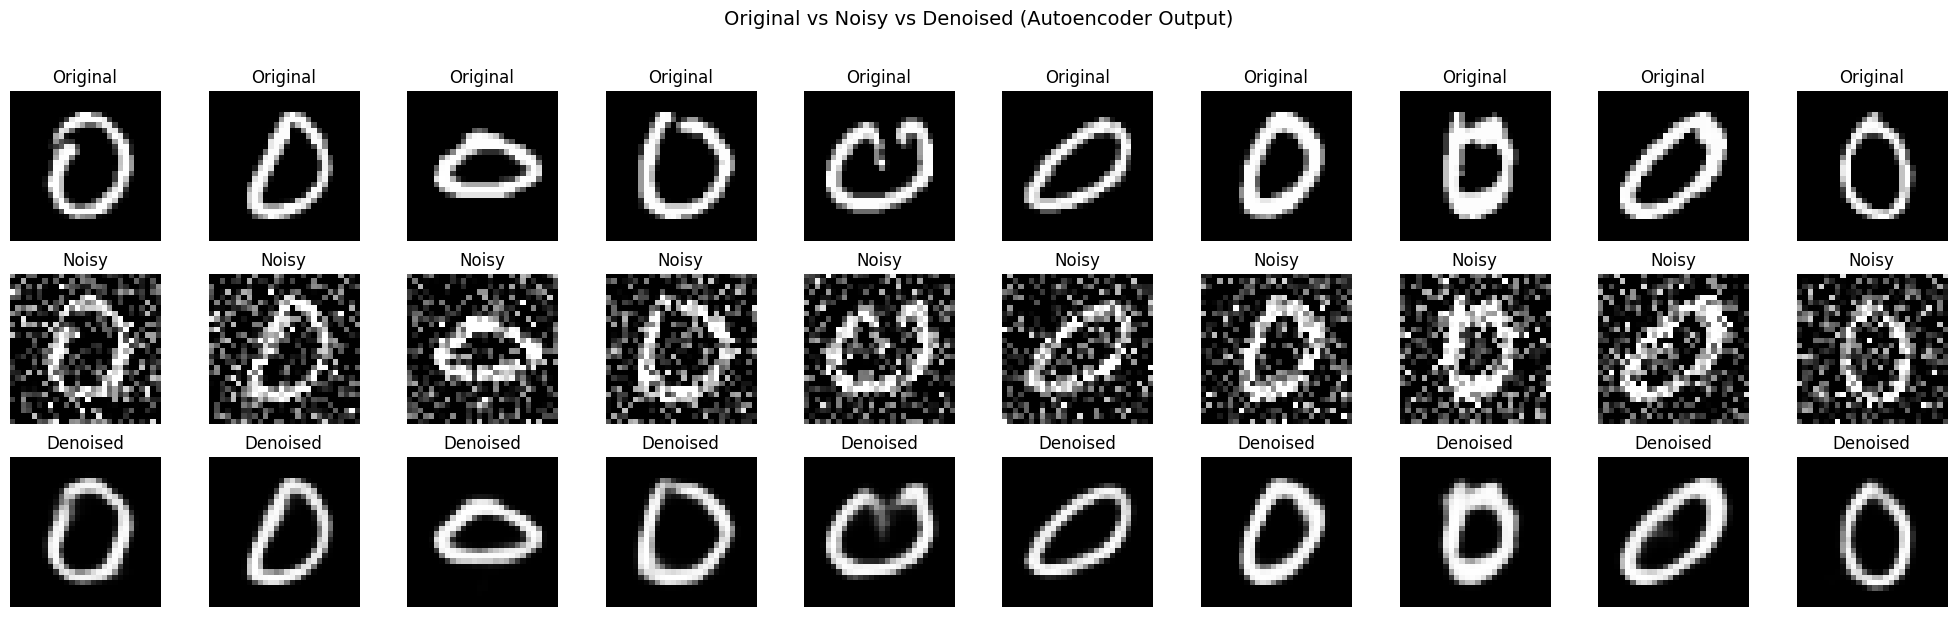

In [11]:
n = 10  # number of digits to display
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised (reconstructed)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("Original vs Noisy vs Denoised (Autoencoder Output)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### (Optional) Quantify reconstruction quality with a metric

This isn't required by the assignment, but it gives you numbers to back up the
visual comparison if you want to talk about it in the observations section.


In [12]:
from skimage.metrics import peak_signal_noise_ratio as psnr

sample_psnr_noisy = psnr(x_test[:200], x_test_noisy[:200])
sample_psnr_denoised = psnr(x_test[:200], denoised_images[:200])

print(f"Average PSNR (noisy vs clean):     {sample_psnr_noisy:.2f} dB")
print(f"Average PSNR (denoised vs clean):  {sample_psnr_denoised:.2f} dB")


Average PSNR (noisy vs clean):     10.98 dB
Average PSNR (denoised vs clean):  20.87 dB


## Observations

- **Training behaviour:** The model was trained for the full 20 epochs, with EarlyStopping not triggering — meaning validation loss kept improving throughout. Training loss ended at 0.0854 and validation loss at 0.0851, a very small gap between them, indicating no overfitting.
- **Denoising performance:** The autoencoder was able to recover the digit shape from noisy input at a noise factor of 0.4. Digits remained recognizable after denoising, though edges came out slightly smoothed rather than sharp — expected for a model trained with a reconstruction-based loss (binary crossentropy).
- **PSNR change:** Average PSNR improved from 10.98 dB (noisy vs clean) to 20.87 dB (denoised vs clean) — roughly a 10 dB improvement, giving a quantitative confirmation of the visual denoising quality.
- **Challenges:** No training instability or errors were observed; the loss curve decreased smoothly across all 20 epochs.
- **Possible improvements (optional/innovation):** Could experiment with a higher noise factor to test robustness, a deeper encoder-decoder, or MSE loss instead of binary crossentropy to compare reconstruction sharpness.